In [1]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)


In [2]:


# project_root = Path.cwd().resolve()
# while not (project_root / "data").exists() and project_root != project_root.parent:
#     project_root = project_root.parent

# bronze_path = project_root / "data" / "bronze" / "bronze_liste_communes_france.csv"
# silver_path = project_root / "data" / "silver" / "silver_liste_communes_france.csv"
# silver_path.parent.mkdir(parents=True, exist_ok=True)  # ensure /data/silver exists

# # Read bronze
# df_bronze = pd.read_csv(bronze_path, sep=";", dtype=str, encoding="utf-8")

# # Transform -> silver dataframe
# df_silver = df_bronze.copy()

# # ... your cleaning / renaming / casting on df_silver ...

# # Save silver
# df_silver.to_csv(silver_path, sep=";", index=False, encoding="utf-8")
# print(f"Wrote silver: {silver_path}")


In [3]:
# df_silver.dtypes

In [4]:
# string_cols = [
#     "code_insee","nom_standard","nom_sans_pronom","nom_a","nom_de","nom_sans_accent",
#     "nom_standard_majuscule","typecom","typecom_texte","reg_code","reg_nom","dep_code",
#     "dep_nom","canton_code","canton_nom","epci_code","epci_nom","academie_code",
#     "academie_nom","code_postal","codes_postaux","zone_emploi","code_insee_centre_zone_emploi",
#     "code_unite_urbaine","nom_unite_urbaine","type_commune_unite_urbaine",
#     "statut_commune_unite_urbaine","grille_densite_texte","niveau_equipements_services_texte",
#     "gentile","url_wikipedia","url_villedereve","extraction_source_url","source_file_name"
# ]

# int_cols = [
#     "taille_unite_urbaine","population","superficie_hectare","superficie_km2","densite",
#     "altitude_moyenne","altitude_minimale","altitude_maximale","grille_densite",
#     "niveau_equipements_services"
# ]

# float_cols = ["latitude_mairie","longitude_mairie","latitude_centre","longitude_centre"]

# for c in string_cols:
#     if c in df_silver.columns:
#         df_silver[c] = df_silver[c].str.strip().astype("string")

# for c in int_cols:
#     if c in df_silver.columns:
#         df_silver[c] = pd.to_numeric(df_silver[c], errors="coerce").astype("Int64")

# for c in float_cols:
#     if c in df_silver.columns:
#         df_silver[c] = pd.to_numeric(df_silver[c].str.replace(",", ".", regex=False), errors="coerce").astype("Float64")

# if "ingestion_timestamp" in df_silver.columns:
#     df_silver["ingestion_timestamp"] = pd.to_datetime(df_silver["ingestion_timestamp"], errors="coerce")

# print(df_silver.dtypes)


In [5]:
# print(df_silver.columns.tolist())

In [6]:
# # Save silver
# df_silver.to_csv(silver_path, sep=";", index=False, encoding="utf-8")
# print(f"Wrote silver: {silver_path}")

In [7]:

project_root = Path.cwd().resolve()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

bronze_path = project_root / "data" / "bronze" / "bronze_liste_communes_france.csv"
silver_path = project_root / "data" / "silver" / "silver_liste_communes_france.csv"
silver_path.parent.mkdir(parents=True, exist_ok=True)

# Read bronze
df_bronze = pd.read_csv(
    bronze_path,
    sep=";",
    dtype=str,
    encoding="utf-8"
)

# Normalize column names
df_bronze.columns = [c.strip() for c in df_bronze.columns]

# Start silver
df_silver = df_bronze.copy()



In [8]:
# Drop useless technical column 
if "Unnamed: 0" in df_silver.columns:
    df_silver = df_silver.drop(columns=["Unnamed: 0"])

 
# Keep useful columns only
 
cols_keep = [
    "code_insee",
    "nom_standard",
    "typecom",
    "typecom_texte",
    "reg_code",
    "reg_nom",
    "dep_code",
    "dep_nom",
    "canton_code",
    "canton_nom",
    "epci_code",
    "epci_nom",
    "academie_code",
    "academie_nom",
    "code_postal",
    "codes_postaux",
    "zone_emploi",
    "code_insee_centre_zone_emploi",
    "code_unite_urbaine",
    "nom_unite_urbaine",
    "taille_unite_urbaine",
    "type_commune_unite_urbaine",
    "statut_commune_unite_urbaine",
    "population",
    "superficie_hectare",
    "superficie_km2",
    "densite",
    "altitude_moyenne",
    "altitude_minimale",
    "altitude_maximale",
    "latitude_mairie",
    "longitude_mairie",
    "latitude_centre",
    "longitude_centre",
    "grille_densite",
    "grille_densite_texte",
    "niveau_equipements_services",
    "niveau_equipements_services_texte",
    "gentile",
    "extraction_source_url",
    "ingestion_timestamp",
    "source_file_name",
]

existing_cols = [c for c in cols_keep if c in df_silver.columns]
df_silver = df_silver[existing_cols].copy()

 
# Helpers
 
def clean_string(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip()

def to_int_nullable(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def to_float_nullable(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype("string").str.replace(",", ".", regex=False),
        errors="coerce"
    ).astype("Float64")

 
# Cast strings
 
string_cols = [
    "code_insee",
    "nom_standard",
    "typecom",
    "typecom_texte",
    "reg_code",
    "reg_nom",
    "dep_code",
    "dep_nom",
    "canton_code",
    "canton_nom",
    "epci_code",
    "epci_nom",
    "academie_code",
    "academie_nom",
    "code_postal",
    "codes_postaux",
    "zone_emploi",
    "code_insee_centre_zone_emploi",
    "code_unite_urbaine",
    "nom_unite_urbaine",
    "type_commune_unite_urbaine",
    "statut_commune_unite_urbaine",
    "grille_densite_texte",
    "niveau_equipements_services_texte",
    "gentile",
    "extraction_source_url",
    "source_file_name",
]

for col in string_cols:
    if col in df_silver.columns:
        df_silver[col] = clean_string(df_silver[col])

# Preserve leading zeros explicitly on code fields
code_cols = [
    "code_insee",
    "reg_code",
    "dep_code",
    "canton_code",
    "epci_code",
    "academie_code",
    "code_postal",
    "zone_emploi",
    "code_insee_centre_zone_emploi",
    "code_unite_urbaine",
]
for col in code_cols:
    if col in df_silver.columns:
        df_silver[col] = clean_string(df_silver[col])

 
# Cast integers
 
int_cols = [
    "taille_unite_urbaine",
    "population",
    "superficie_hectare",
    "superficie_km2",
    "densite",
    "altitude_moyenne",
    "altitude_minimale",
    "altitude_maximale",
    "grille_densite",
    "niveau_equipements_services",
]

for col in int_cols:
    if col in df_silver.columns:
        df_silver[col] = to_int_nullable(df_silver[col])

 
# Cast floats
 
float_cols = [
    "latitude_mairie",
    "longitude_mairie",
    "latitude_centre",
    "longitude_centre",
]

for col in float_cols:
    if col in df_silver.columns:
        df_silver[col] = to_float_nullable(df_silver[col])

 
# Cast timestamp
 
if "ingestion_timestamp" in df_silver.columns:
    df_silver["ingestion_timestamp"] = pd.to_datetime(
        df_silver["ingestion_timestamp"],
        errors="coerce"
    )

 
# Save silver
 
df_silver.to_csv(silver_path, sep=";", index=False, encoding="utf-8")

print(f"Wrote silver: {silver_path}")
print(f"Shape: {df_silver.shape}")
print("\nDtypes:")
print(df_silver.dtypes)
print("\nSample:")
display(df_silver.head())

Wrote silver: /Users/zainfrayha/Documents/EPSI/MSPR/electio-analytics-poc/data/silver/silver_liste_communes_france.csv
Shape: (266, 42)

Dtypes:
code_insee                           string[python]
nom_standard                         string[python]
typecom                              string[python]
typecom_texte                        string[python]
reg_code                             string[python]
reg_nom                              string[python]
dep_code                             string[python]
dep_nom                              string[python]
canton_code                          string[python]
canton_nom                           string[python]
epci_code                            string[python]
epci_nom                             string[python]
academie_code                        string[python]
academie_nom                         string[python]
code_postal                          string[python]
codes_postaux                        string[python]
zone_emploi            

,code_insee,nom_standard,typecom,typecom_texte,reg_code,reg_nom,dep_code,dep_nom,canton_code,canton_nom,epci_code,epci_nom,academie_code,academie_nom,code_postal,codes_postaux,zone_emploi,code_insee_centre_zone_emploi,code_unite_urbaine,nom_unite_urbaine,taille_unite_urbaine,type_commune_unite_urbaine,statut_commune_unite_urbaine,population,superficie_hectare,superficie_km2,densite,altitude_moyenne,altitude_minimale,altitude_maximale,latitude_mairie,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,extraction_source_url,ingestion_timestamp,source_file_name
0,69001,Affoux,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6910,Tarare,200040566,CA de l'Ouest Rhodanien,10,Lyon,69170,69170,08430,69243,69000,<NA>,0,HORS UNITE URBAINE,H,395,1068,11,37,750,498,960,45.845,4.404,45.844,4.414,6,Rural à habitat dispersé,0,communes non pôle,Affousiens,https://www.data.gouv.fr/api/1/datasets/r/f5df...,2026-03-18 14:30:18.054404,liste_communes_france.csv
1,69002,Aigueperse,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6911,Thizy-les-Bourgs,200067817,CC Saône-Beaujolais,10,Lyon,69790,69790,08434,69264,69000,<NA>,0,HORS UNITE URBAINE,H,243,1290,13,19,489,403,610,46.277,4.435,46.28,4.423,7,Rural à habitat très dispersé,0,communes non pôle,Aiguepersirons,https://www.data.gouv.fr/api/1/datasets/r/f5df...,2026-03-18 14:30:18.054404,liste_communes_france.csv
2,69003,Albigny-sur-Saône,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6999,Lyon,200046977,Métropole de Lyon,10,Lyon,69250,69250,08421,69123,00760,Lyon,7,UNITE URBAINE,B,2991,266,3,1124,223,167,0,45.871,4.832,45.864,4.831,4,Ceintures urbaines,2,centres intermédiaires d'équipements et de ser...,Albignolais,https://www.data.gouv.fr/api/1/datasets/r/f5df...,2026-03-18 14:30:18.054404,liste_communes_france.csv
3,69004,Alix,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6904,Val d'Oingt,200040574,CC Beaujolais Pierres Dorées,10,Lyon,69380,69380,08421,69123,69301,Val d'Oingt,3,UNITE URBAINE,B,766,360,4,213,310,258,408,45.911,4.653,45.917,4.655,6,Rural à habitat dispersé,0,communes non pôle,Alixois,https://www.data.gouv.fr/api/1/datasets/r/f5df...,2026-03-18 14:30:18.054404,liste_communes_france.csv
4,69005,Ambérieux,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6901,Anse,200040574,CC Beaujolais Pierres Dorées,10,Lyon,69480,69480,08421,69123,00760,Lyon,7,UNITE URBAINE,B,607,461,5,132,171,167,176,45.928,4.737,45.929,4.741,4,Ceintures urbaines,1,centres locaux d'équipements et de services,"Ambarrois, Ambarroises",https://www.data.gouv.fr/api/1/datasets/r/f5df...,2026-03-18 14:30:18.054404,liste_communes_france.csv


### Missingno pour df_silver (Communes France) ###



<Axes: >

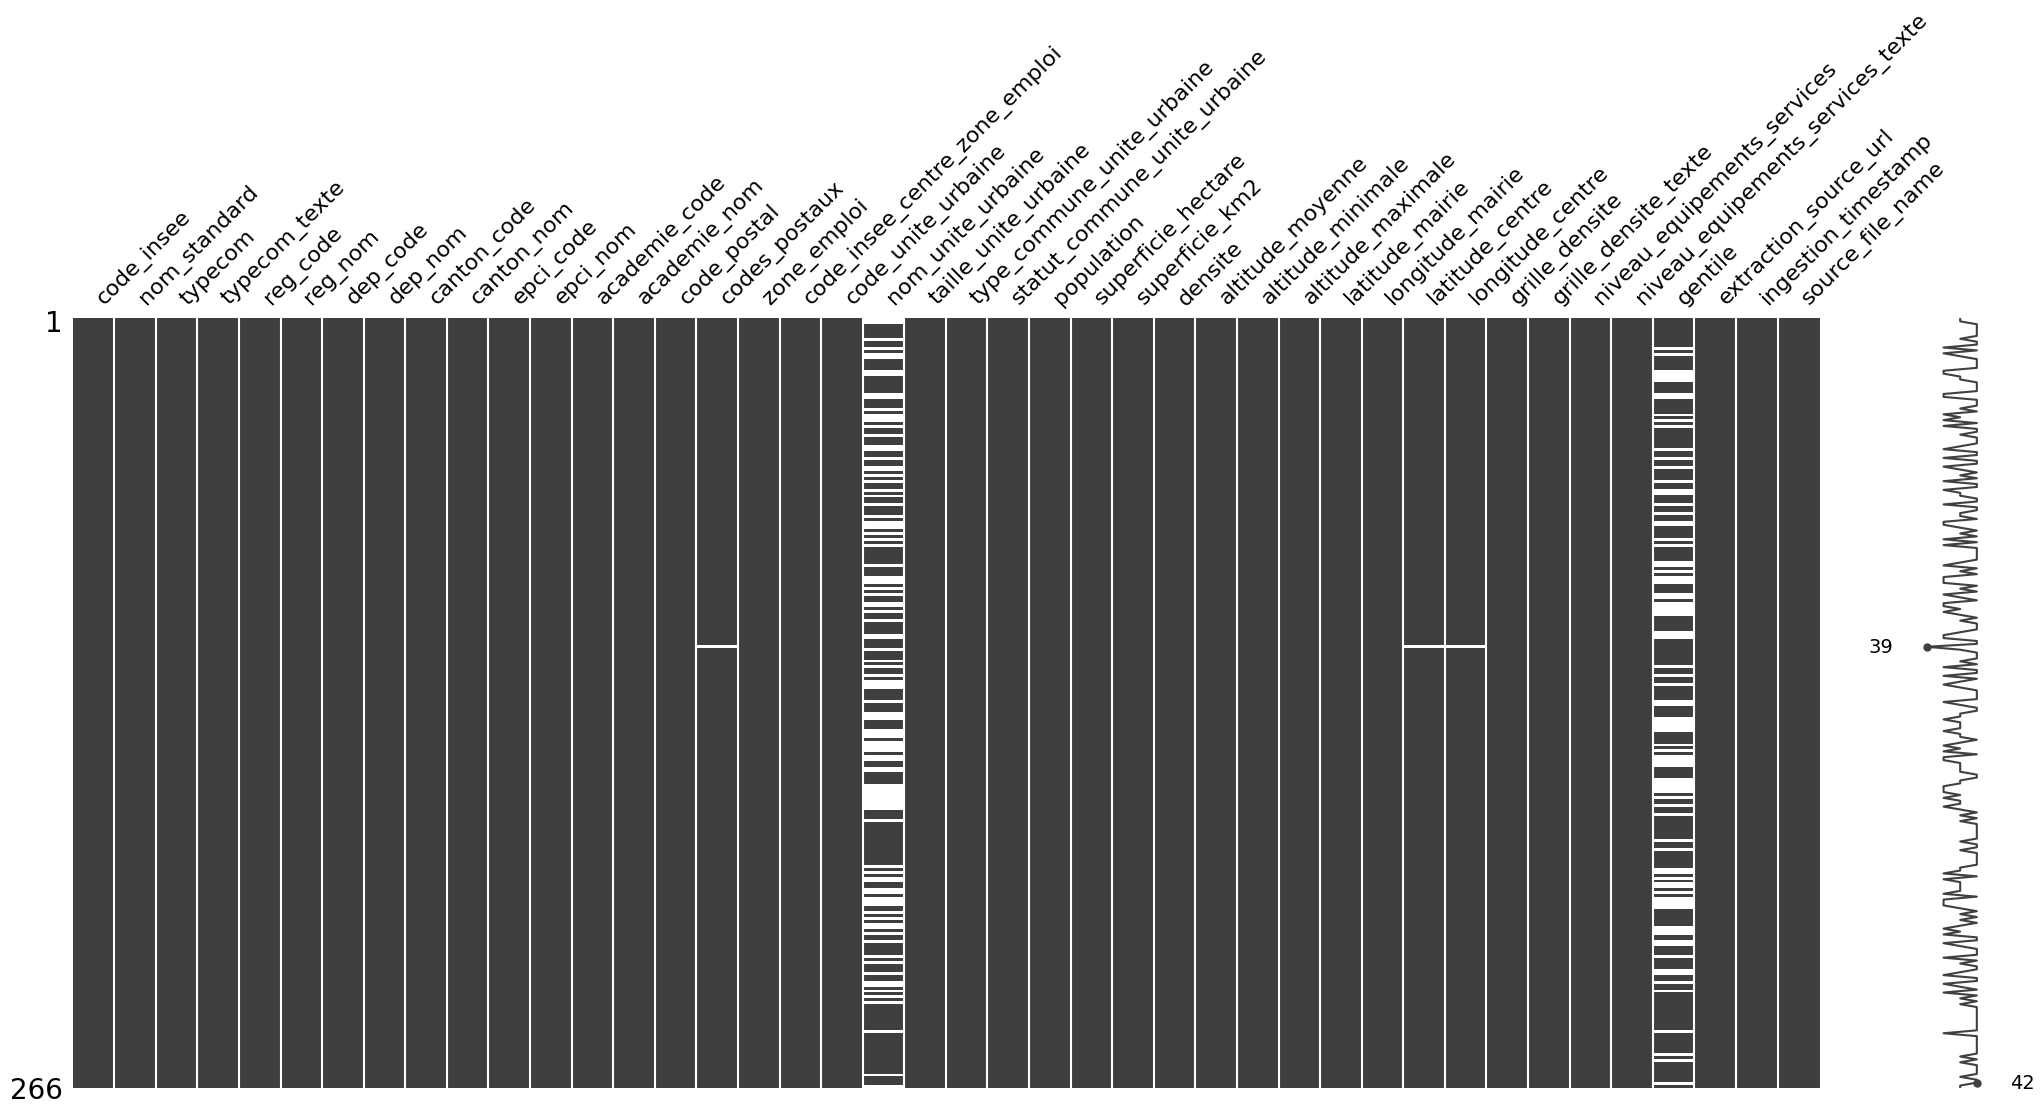

In [9]:
import missingno as msno

# Define the name for the title
name = "df_silver (Communes France)"

print(f"### Missingno pour {name} ###\n")

# Generate the sparsity matrix to visualize missing data
msno.matrix(df_silver)

<Axes: >

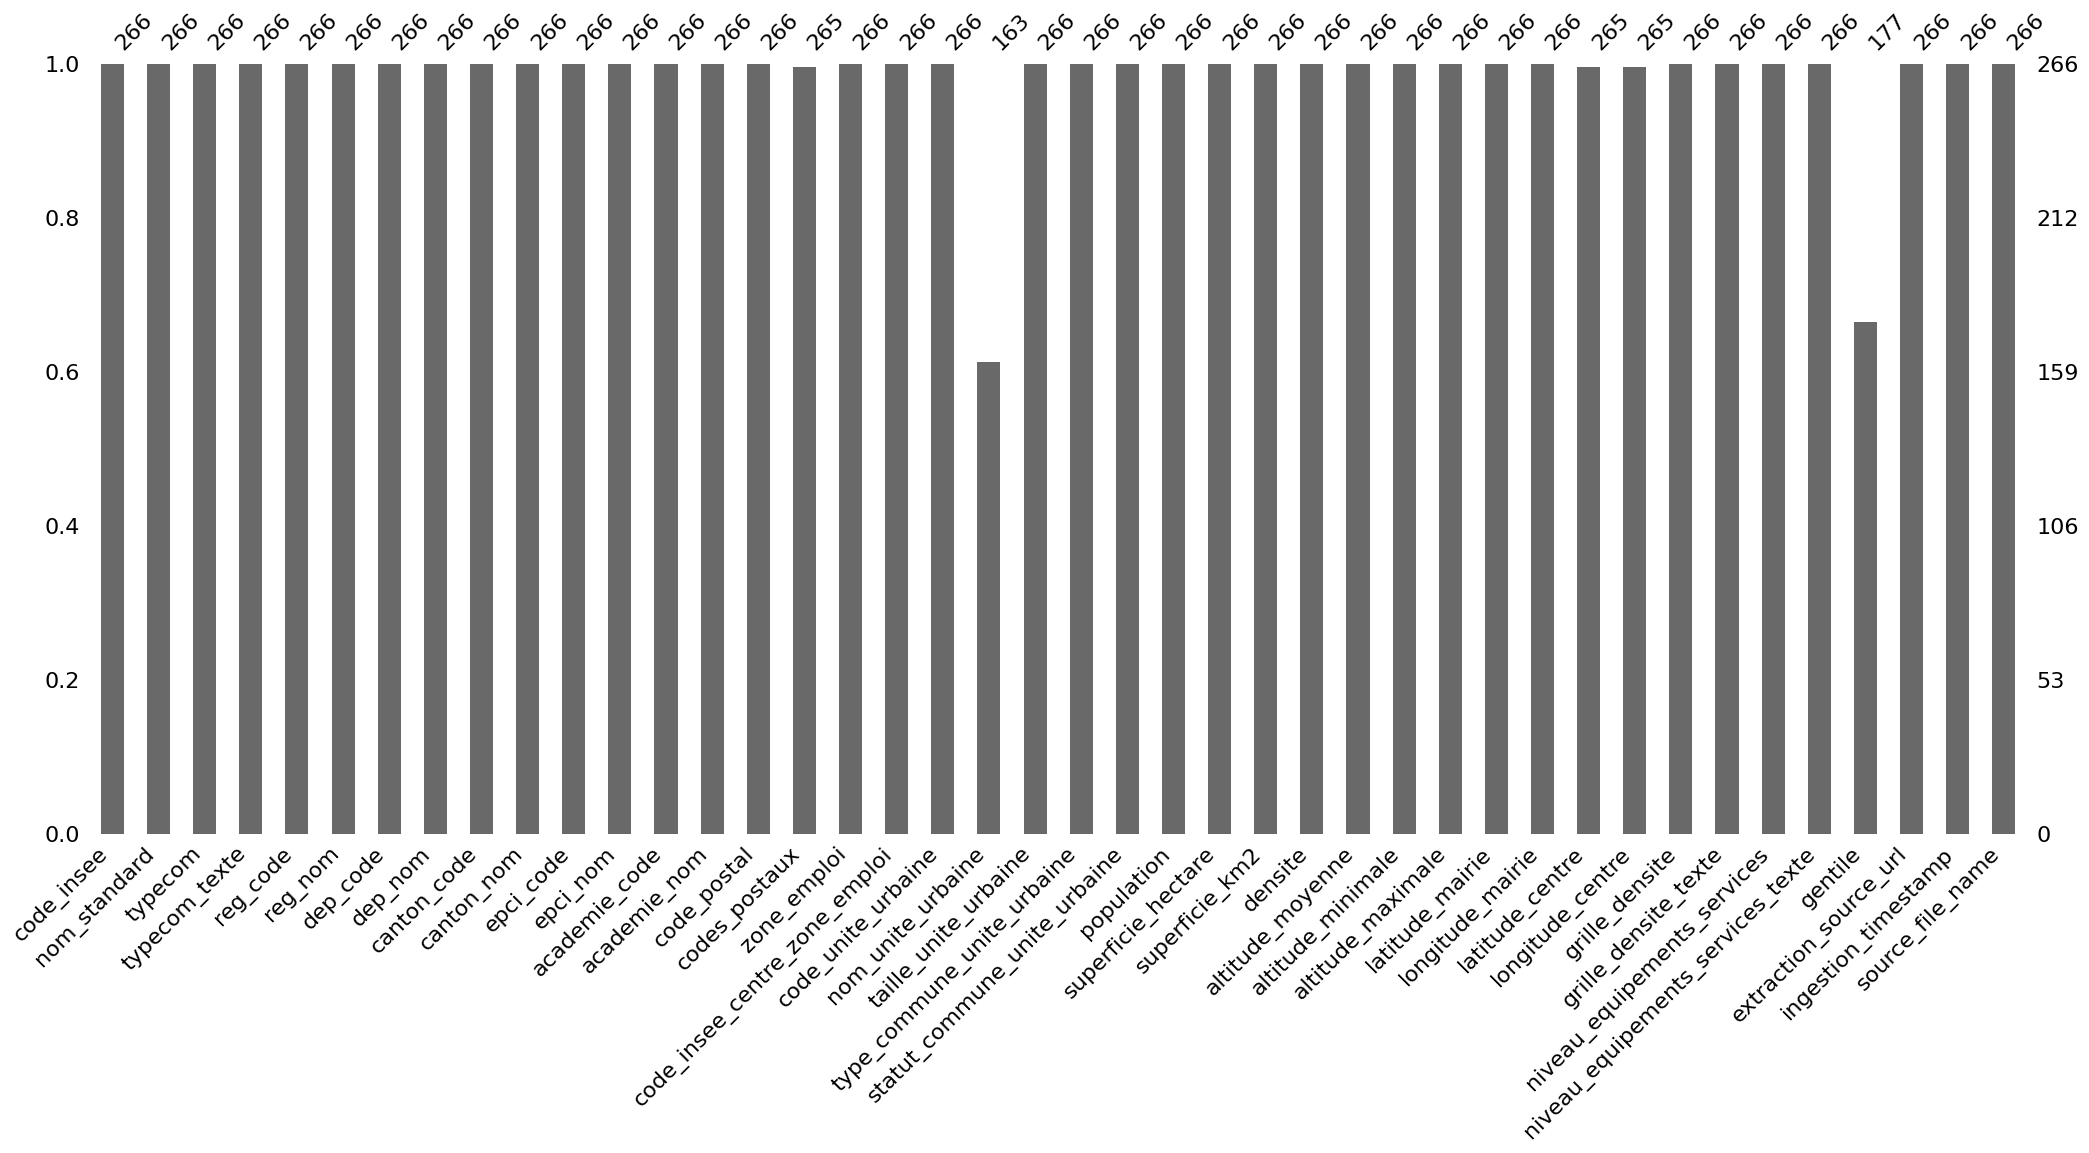

In [10]:
msno.bar(df_silver)

In [11]:
unique_counts = df_silver.nunique(dropna=False).reset_index()
unique_counts.columns = ["column", "unique_count"]
display(unique_counts)


,column,unique_count
0,code_insee,266
1,nom_standard,266
2,typecom,1
3,typecom_texte,1
4,reg_code,1
5,reg_nom,1
6,dep_code,1
7,dep_nom,1
8,canton_code,14
9,canton_nom,14


In [12]:
print(f"Nombre de lignes : {df_silver.shape[0]}")
print(f"Nombre de colonnes : {df_silver.shape[1]}")


Nombre de lignes : 266
Nombre de colonnes : 42


In [13]:
print(f"### Statistiques descriptives pour {name} ###\n")
display(df_silver.describe(include='all'))

### Statistiques descriptives pour df_silver (Communes France) ###



,code_insee,nom_standard,typecom,typecom_texte,reg_code,reg_nom,dep_code,dep_nom,canton_code,canton_nom,epci_code,epci_nom,academie_code,academie_nom,code_postal,codes_postaux,zone_emploi,code_insee_centre_zone_emploi,code_unite_urbaine,nom_unite_urbaine,taille_unite_urbaine,type_commune_unite_urbaine,statut_commune_unite_urbaine,population,superficie_hectare,superficie_km2,densite,altitude_moyenne,altitude_minimale,altitude_maximale,latitude_mairie,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,extraction_source_url,ingestion_timestamp,source_file_name
count,266,266,266,266,266,266,266,266,266,266,266,266,266,266,266,265,266,266,266,163,266.0,266,266,266.0,266.0,266.0,266.0,266.0,266.0,266.0,266.0,266.0,265.0,265.0,266.0,266,266.0,266,177,266,266,266
unique,266,266,1,1,1,1,1,1,14,14,13,13,1,1,81,107,5,5,26,25,<NA>,2,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7,<NA>,5,174,1,NaN,1
top,69001,Affoux,COM,commune,84,Auvergne-Rhône-Alpes,69,Rhône,6999,Lyon,200046977,Métropole de Lyon,10,Lyon,69380,69380,08421,69123,69000,Lyon,<NA>,UNITE URBAINE,B,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Rural à habitat dispersé,<NA>,centres locaux d'équipements et de services,"Stéphanois, Stéphanoises",https://www.data.gouv.fr/api/1/datasets/r/f5df...,NaN,liste_communes_france.csv
freq,1,1,266,266,266,266,266,266,58,58,58,58,266,266,14,14,165,165,103,102,<NA>,163,136,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,97,<NA>,104,2,266,NaN,266
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.31203,NaN,NaN,7079.612782,1140.669173,11.402256,612.879699,383.932331,264.530075,541.045113,45.852929,4.664959,45.853717,4.663019,4.518797,NaN,1.090226,NaN,NaN,NaN,2026-03-18 14:30:18.054403840,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,110.0,39.0,0.0,14.0,171.0,0.0,0.0,45.464,4.31,45.474,4.314,1.0,NaN,0.0,NaN,NaN,NaN,2026-03-18 14:30:18.054404,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,829.5,575.5,6.0,74.5,241.5,178.25,310.25,45.709,4.53675,45.709,4.535,4.0,NaN,0.0,NaN,NaN,NaN,2026-03-18 14:30:18.054404096,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,1751.5,1016.0,10.0,197.0,331.5,227.0,480.5,45.837,4.6705,45.839,4.668,5.0,NaN,1.0,NaN,NaN,NaN,2026-03-18 14:30:18.054404096,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,4433.75,1529.75,15.0,579.25,522.75,328.25,773.0,45.9845,4.77875,45.986,4.774,6.0,NaN,2.0,NaN,NaN,NaN,2026-03-18 14:30:18.054404096,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,522250.0,4790.0,48.0,10903.0,815.0,640.0,3114.0,46.277,5.112,46.28,5.103,7.0,NaN,4.0,NaN,NaN,NaN,2026-03-18 14:30:18.054404,NaN


In [14]:
print(f"### Nombre de valeurs manquantes pour {name} ###\n")
display(df_silver.isnull().sum())

### Nombre de valeurs manquantes pour df_silver (Communes France) ###



code_insee                             0
nom_standard                           0
typecom                                0
typecom_texte                          0
reg_code                               0
reg_nom                                0
dep_code                               0
dep_nom                                0
canton_code                            0
canton_nom                             0
epci_code                              0
epci_nom                               0
academie_code                          0
academie_nom                           0
code_postal                            0
codes_postaux                          1
zone_emploi                            0
code_insee_centre_zone_emploi          0
code_unite_urbaine                     0
nom_unite_urbaine                    103
taille_unite_urbaine                   0
type_commune_unite_urbaine             0
statut_commune_unite_urbaine           0
population                             0
superficie_hecta

In [15]:
# Le pourcentage de valeur manquante de chaque colonnes
print(f"### Pourcentage de valeurs manquantes pour {name} ###\n")
display((df_silver.isnull().sum() / len(df_silver)) * 100)

### Pourcentage de valeurs manquantes pour df_silver (Communes France) ###



code_insee                            0.000000
nom_standard                          0.000000
typecom                               0.000000
typecom_texte                         0.000000
reg_code                              0.000000
reg_nom                               0.000000
dep_code                              0.000000
dep_nom                               0.000000
canton_code                           0.000000
canton_nom                            0.000000
epci_code                             0.000000
epci_nom                              0.000000
academie_code                         0.000000
academie_nom                          0.000000
code_postal                           0.000000
codes_postaux                         0.375940
zone_emploi                           0.000000
code_insee_centre_zone_emploi         0.000000
code_unite_urbaine                    0.000000
nom_unite_urbaine                    38.721805
taille_unite_urbaine                  0.000000
type_commune_